In [1]:
import os
import sys
import json
from pathlib import Path
import random
import inspect
from pprint import pprint

from dotenv import load_dotenv, find_dotenv
# 1. Locate and load the environment variables from the .env configuration file
dotenv_path = find_dotenv()
load_dotenv(dotenv_path)

# 2. Extract configuration variables from the environment
PROJECT_ROOT = os.getenv("PROJECT_ROOT")
REPOS_DIR = os.getenv("REPOS_DIR")
DATA_DIR = os.getenv("DATA_DIR")

project_root = Path(PROJECT_ROOT).resolve()
if str(project_root) not in sys.path:
    sys.path.append(str(project_root))

In [2]:
def generate_repo_map(base_dir: str, prefix: str = "apache/") -> dict[str, str]:
    """
    Scans a base directory for valid git repositories and constructs
    a REPO_MAP dictionary compatible with the CommitDataLoader mapping schema.
    """
    repo_map = {}
    base_path = Path(base_dir)
    
    if not base_path.exists():
        print(f"⚠️ Warning: Base directory '{base_dir}' does not exist.")
        return repo_map

    # Iterate through all direct items in the repos folder
    for item in base_path.iterdir():
        if item.is_dir():
            # Check if it contains a hidden .git directory to verify it's a real repo
            git_dir = item / ".git"
            if git_dir.exists():
                # Reconstruct the project key name (e.g., "apache/groovy")
                project_key = f"{prefix}{item.name.lower()}"
                
                # Assign the absolute string path as the value
                repo_map[project_key] = str(item.resolve())
                
    return repo_map

# Run the auto-generation mapping
REPO_MAP = generate_repo_map(REPOS_DIR, prefix="apache/")

# Print out your freshly discovered mappings
print("📂 Automatically generated REPO_MAP mappings:")
print("-" * 50)
for project, local_path in REPO_MAP.items():
    print(f"  '{project}'")
print("-" * 50)

📂 Automatically generated REPO_MAP mappings:
--------------------------------------------------
  'apache/activemq'
  'apache/camel'
  'apache/cassandra'
  'apache/flink'
  'apache/groovy'
  'apache/hadoop'
  'apache/hadoop-hdfs'
  'apache/hadoop-mapreduce'
  'apache/hbase'
  'apache/hive'
  'apache/ignite'
  'apache/kafka'
  'apache/spark'
  'apache/zeppelin'
  'apache/zookeeper'
--------------------------------------------------


In [3]:
import os
from pathlib import Path
import git

def get_initial_repo_map(repo_path: str):
    """
    Locates the very first commit (root commit) of the repository 
    and prints its metadata and structural file tree.
    """
    print(f"🔄 Opening repository at: {repo_path}")
    try:
        repo = git.Repo(repo_path)
        
        print("🔍 Locating the initial root commit...")
        # Method 1: Ask git for commits that have 0 parents (the absolute root)
        # rev_list returns a list of strings, so we take the last one found
        root_commits = repo.git.rev_list("--max-parents=0", "HEAD").splitlines()
        
        if not root_commits:
            print("❌ Could not find a root commit. The repository might be empty.")
            return
            
        initial_commit_sha = root_commits[-1] # Take the oldest root if there are multiple roots
        initial_commit = repo.commit(initial_commit_sha)
        
        print(f"✅ Initial Commit Found!")
        print(f"📌 SHA:            {initial_commit.hexsha}")
        print(f"👤 Author:         {initial_commit.author.name} <{initial_commit.author.email}>")
        print(f"📅 Date:           {initial_commit.authored_datetime.isoformat()}")
        print(f"📝 Message:        {initial_commit.message.strip()}")
        print("-" * 70)
        
        # 🗺️ Generate the Repo Map of this exact initial state
        print(f"🗺️  INITIAL REPO MAP (At Commit {initial_commit.hexsha[:8]}):")
        
        def traverse_tree(tree, current_depth=0):
            indent = "   " * current_depth
            
            # Print Directories (Sub-trees)
            for subtree in sorted(tree.trees, key=lambda t: t.name):
                print(f"{indent}├── 📁 {subtree.name}/")
                traverse_tree(subtree, current_depth + 1)
                
            # Print Files (Blobs)
            for blob in sorted(tree.blobs, key=lambda b: b.name):
                print(f"{indent}├── 📄 {blob.name}")

        print(f"📁 [Root: {Path(repo_path).name}]")
        traverse_tree(initial_commit.tree)
        
    except git.NoSuchPathError:
        print(f"❌ Error: The path '{repo_path}' does not exist.")
    except git.InvalidGitRepositoryError:
        print(f"❌ Error: Valid git repository not found at '{repo_path}'.")
    except Exception as e:
        print(f"💥 Error retrieving initial version: {e}")

# --- RUN THE TEST ---
TARGET_REPO = REPO_MAP.get("apache/hive")

get_initial_repo_map(repo_path=TARGET_REPO)

🔄 Opening repository at: E:\repos\hive
🔍 Locating the initial root commit...
✅ Initial Commit Found!
📌 SHA:            65da10218eaac25c47a69f6965002a1ac4bfcac3
👤 Author:         Owen O'Malley <omalley@apache.org>
📅 Date:           2008-09-02T23:58:59+00:00
📝 Message:        HADOOP-3601. Add a new contrib module for Hive, which is a sql-like
query processing tool that uses map/reduce. (Ashish Thusoo via omalley)


git-svn-id: https://svn.apache.org/repos/asf/hadoop/core/trunk/src/contrib/hive@691438 13f79535-47bb-0310-9956-ffa450edef68
----------------------------------------------------------------------
🗺️  INITIAL REPO MAP (At Commit 65da1021):
📁 [Root: hive]
├── 📁 ant/
   ├── 📁 src/
      ├── 📁 org/
         ├── 📁 apache/
            ├── 📁 hadoop/
               ├── 📁 hive/
                  ├── 📁 ant/
                     ├── 📄 QTestGenTask.java
                     ├── 📄 antlib.xml
   ├── 📄 build.xml
├── 📁 bin/
   ├── 📄 hive
   ├── 📄 hive-config.sh
├── 📁 cli/
   ├── 📁 lib/
      ├

In [4]:
import os
import pandas as pd
import git
from pathlib import Path

def analyze_all_repositories(repo_map: dict):
    """
    Traverses all projects in repo_map, computes commit topologies 
    (parent distributions), and summarizes critical repository scale stats.
    """
    print("📊 Initiating Git repository topology and stats analysis...")
    print("-" * 80)
    
    analysis_records = []
    
    for project_name, repo_path in repo_map.items():
        if not repo_path or not os.path.exists(repo_path):
            print(f"⚠️ Skipping '{project_name}': Path does not exist ({repo_path})")
            continue
            
        print(f"🔄 Analyzing: {project_name}...")
        try:
            repo = git.Repo(repo_path)
            
            # 1. Gather all commits to scan parent distributions
            # Using custom format %P gives us a space-separated string of parent SHAs per commit
            all_commits_parents = repo.git.log("--all", "--format=%P").splitlines()
            total_commits = len(all_commits_parents)
            
            # 2. Compute parent frequencies
            root_count = 0        # 0 parents
            standard_count = 0    # 1 parent
            merge_count = 0       # 2 or more parents
            
            for line in all_commits_parents:
                parent_shas = line.strip().split()
                p_count = len(parent_shas)
                
                if p_count == 0:
                    root_count += 1
                elif p_count == 1:
                    standard_count += 1
                else:
                    merge_count += 1
            
            # 3. Gather general volume stats from HEAD state
            head_commit = repo.head.commit
            
            # Count tracked files at HEAD via its tree
            def count_tracked_files(tree):
                count = len(tree.blobs)
                for subtree in tree.trees:
                    count += count_tracked_files(subtree)
                return count
            
            total_tracked_files = count_tracked_files(head_commit.tree)
            
            # Collect data for dataframe compilation
            analysis_records.append({
                "Project Name": project_name,
                "Total Commits": total_commits,
                "Root Commits (0 Parents)": root_count,
                "Standard Commits (1 Parent)": standard_count,
                "Merge Commits (2+ Parents)": merge_count,
                "Tracked Files (HEAD)": total_tracked_files,
                "Latest Commit SHA": head_commit.hexsha[:8],
                "Active Branch": repo.active_branch.name if not repo.head.is_detached else "Detached HEAD"
            })
            
        except git.InvalidGitRepositoryError:
            print(f"❌ '{repo_path}' is not a valid Git repository.")
        except Exception as e:
            print(f"💥 Failed processing '{project_name}': {e}")
            
    print("\n" + "="*80)
    print("📈 GLOBAL REPOSITORY TOPOLOGY SUMMARY")
    print("="*80)
    
    # Generate a pandas DataFrame for readable tabular visualization inside your notebook
    df_summary = pd.DataFrame(analysis_records)
    
    # Calculate global totals to add as an ultimate summary row
    if not df_summary.empty:
        # Style formatting to make it clean in Jupyter
        pd.set_option('display.max_columns', None)
        pd.set_option('display.width', 1000)
        
        display(df_summary) # Renders native interactive HTML table inside Jupyter Notebook cells
        
        # Save results to your data path for reference later if needed
        output_csv = Path(next(iter(repo_map.values()))).parent / "repo_topology_stats.csv"
        df_summary.to_csv(output_csv, index=False)
        print(f"\n💾 Summary stats saved to: {output_csv}")
    else:
        print("❌ No repositories were successfully analyzed.")


analyze_all_repositories(repo_map=REPO_MAP)

📊 Initiating Git repository topology and stats analysis...
--------------------------------------------------------------------------------
🔄 Analyzing: apache/activemq...
🔄 Analyzing: apache/camel...
🔄 Analyzing: apache/cassandra...
🔄 Analyzing: apache/flink...
🔄 Analyzing: apache/groovy...
🔄 Analyzing: apache/hadoop...
🔄 Analyzing: apache/hadoop-hdfs...
🔄 Analyzing: apache/hadoop-mapreduce...
🔄 Analyzing: apache/hbase...
🔄 Analyzing: apache/hive...
🔄 Analyzing: apache/ignite...
🔄 Analyzing: apache/kafka...
🔄 Analyzing: apache/spark...
🔄 Analyzing: apache/zeppelin...
🔄 Analyzing: apache/zookeeper...

📈 GLOBAL REPOSITORY TOPOLOGY SUMMARY


,Project Name,Total Commits,Root Commits (0 Parents),Standard Commits (1 Parent),Merge Commits (2+ Parents),Tracked Files (HEAD),Latest Commit SHA,Active Branch
0,apache/activemq,15815,5,14906,904,5431,82351687,main
1,apache/camel,98795,3,98144,648,38024,fb88c219,main
2,apache/cassandra,32805,1,19634,13170,8362,0cdde302,trunk
3,apache/flink,50803,5,50145,653,25994,1719376d,master
4,apache/groovy,40495,12,39599,884,5310,a822b54a,master
5,apache/hadoop,77392,10,76677,705,16406,f6182e56,trunk
6,apache/hadoop-hdfs,1611,0,1586,25,782,b2d2a326,trunk
7,apache/hadoop-mapreduce,1543,0,1540,3,1902,307cb5b3,trunk
8,apache/hbase,61639,4,61551,84,6396,79f14ed4,master
9,apache/hive,23635,0,23257,378,22182,ee6848d2,master



💾 Summary stats saved to: E:\repos\repo_topology_stats.csv


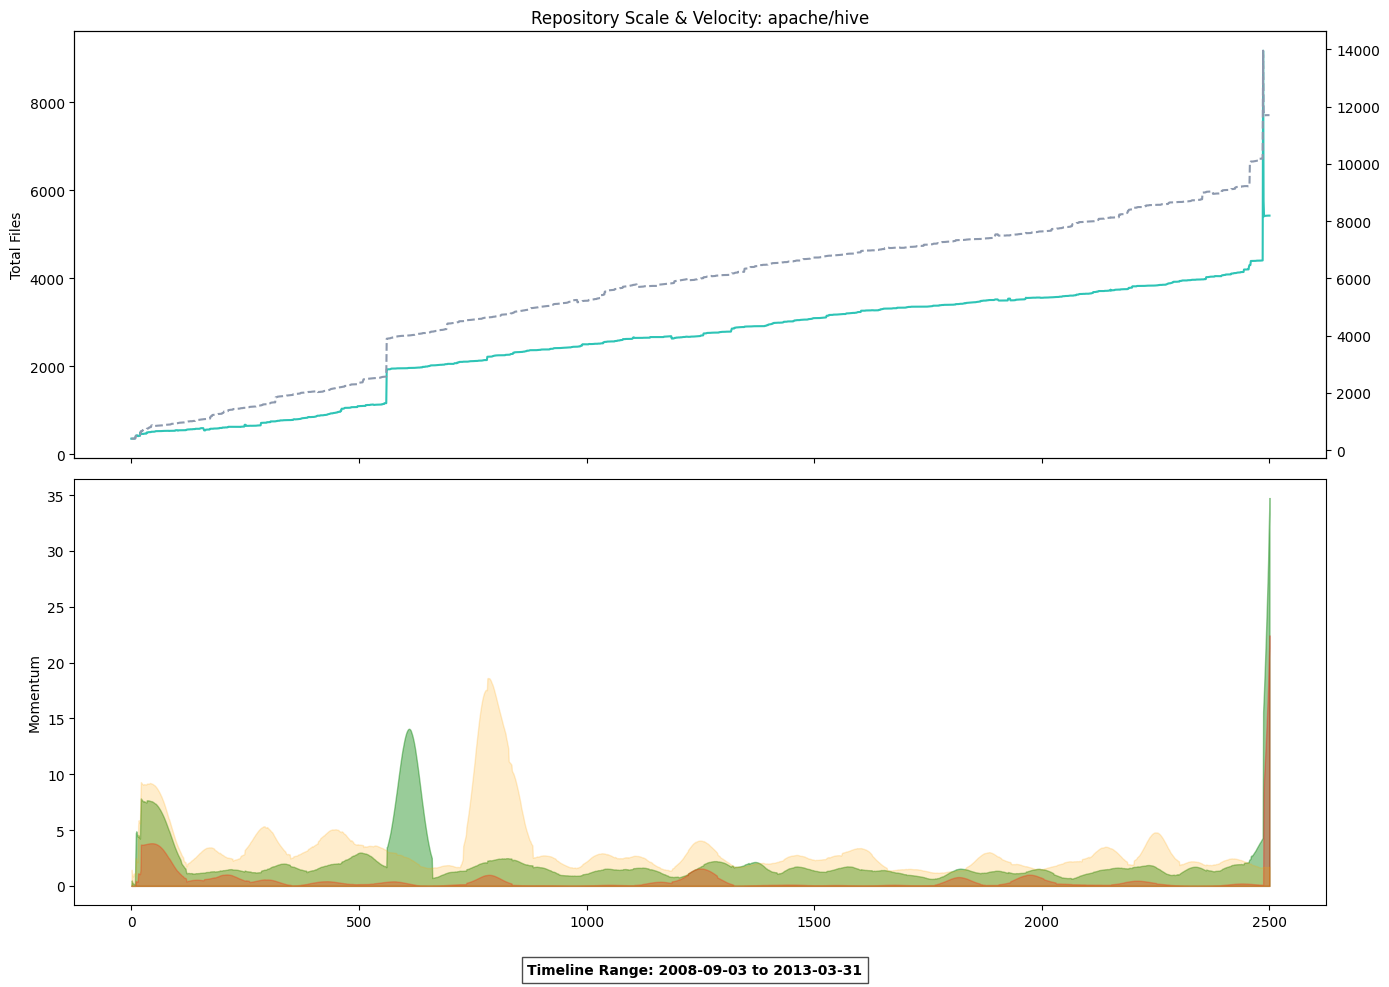

In [ ]:
import os
import numpy as np
import pandas as pd
import git
import matplotlib.pyplot as plt
from IPython.display import display, clear_output
from datetime import datetime

def analyze_and_plot_full_dashboard(repo_map: dict, update_interval_commits: int = 250, smooth_window: int = 150) -> dict:
    """
    Production-ready dashboard:
    1. Prunes root commits from deltas.
    2. Calculates true file inventory.
    3. Renders smooth velocity waves.
    4. Displays calendar date range.
    """
    print("📊 Launching Full-Scale Repository Insight Dashboard...")
    print("=" * 90)
    
    saved_histories = {}
    
    for project_name, repo_path in repo_map.items():
        if not repo_path or not os.path.exists(repo_path):
            print(f"⚠️ Skipping '{project_name}': Path invalid.")
            continue
            
        try:
            repo = git.Repo(repo_path)
            
            # --- PHASE 1: INITIAL SNAPSHOT ---
            print(f"🔄 Initializing baseline for {project_name}...")
            root_commits = [c for c in repo.iter_commits('--all') if c.parents == ()]
            
            initial_java = 0
            initial_non_java = 0
            # Get earliest root date for timeline context
            initial_date = min(c.committed_date for c in root_commits)
            
            for sha in [c.hexsha for c in root_commits]:
                for line in repo.git.ls_tree("-r", sha).splitlines():
                    if line.strip().endswith('.java'): initial_java += 1
                    else: initial_non_java += 1

            # --- PHASE 2: PRUNED TIMELINE ---
            all_commits = list(repo.iter_commits('--all', reverse=True))
            root_shas = set(c.hexsha for c in root_commits)
            commits = [c for c in all_commits if c.hexsha not in root_shas]
            total_commits = len(commits)
            
            history = {
                "commit_dates": [initial_date],
                "java_current_count": [initial_java],
                "non_java_current_count": [initial_non_java],
                "java_added_delta": [0],
                "java_deleted_delta": [0],
                "java_modified_delta": [0]
            }
            
            current_java_pop = initial_java
            current_non_java_pop = initial_non_java
            
            # --- PHASE 3: METRIC ENGINE ---
            for c_idx, commit in enumerate(commits, 1):
                local_java_added = 0
                local_java_deleted = 0
                local_java_modified = 0
                
                for filepath, f_stats in commit.stats.files.items():
                    is_java = filepath.lower().endswith('.java')
                    insertions = f_stats.get("insertions", 0)
                    deletions = f_stats.get("deletions", 0)
                    
                    if deletions == 0 and insertions > 0:
                        if is_java: 
                            current_java_pop += 1
                            local_java_added += 1
                        else: current_non_java_pop += 1
                    elif insertions == 0 and deletions > 0:
                        if is_java: 
                            current_java_pop -= 1
                            local_java_deleted += 1
                        else: current_non_java_pop -= 1
                    elif is_java:
                        local_java_modified += 1
                
                history["commit_dates"].append(commit.committed_date)
                history["java_current_count"].append(max(0, current_java_pop))
                history["non_java_current_count"].append(max(0, current_non_java_pop))
                history["java_added_delta"].append(local_java_added)
                history["java_deleted_delta"].append(local_java_deleted)
                history["java_modified_delta"].append(local_java_modified)
                
                # --- PHASE 4: LIVE DASHBOARD ---
                if c_idx % update_interval_commits == 0 or c_idx == total_commits:
                    clear_output(wait=True)
                    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10), sharex=True)
                    indices = np.arange(len(history["commit_dates"]))
                    
                    # Panel 1: Inventory
                    ax1.plot(indices, history["java_current_count"], color='#2ec4b6', label='Java Population')
                    ax1_twin = ax1.twinx()
                    ax1_twin.plot(indices, history["non_java_current_count"], color='#8d99ae', linestyle='--', label='Non-Java Population')
                    ax1.set_ylabel("Total Files")
                    ax1.set_title(f"Repository Scale & Velocity: {project_name}")
                    
                    # Panel 2: Smooth Momentum
                    s_added = pd.Series(history["java_added_delta"]).rolling(smooth_window, min_periods=1, win_type='gaussian').mean(std=smooth_window/4)
                    s_del = pd.Series(history["java_deleted_delta"]).rolling(smooth_window, min_periods=1, win_type='gaussian').mean(std=smooth_window/4)
                    s_mod = pd.Series(history["java_modified_delta"]).rolling(smooth_window, min_periods=1, win_type='gaussian').mean(std=smooth_window/4)
                    
                    ax2.fill_between(indices, s_added, color='green', alpha=0.4, label='Add Velocity')
                    ax2.fill_between(indices, s_del, color='red', alpha=0.3, label='Delete Velocity')
                    ax2.fill_between(indices, s_mod, color='orange', alpha=0.2, label='Modification Momentum')
                    ax2.set_ylabel("Momentum")
                    
                    # Date Tracker
                    start_d = datetime.fromtimestamp(history["commit_dates"][0]).strftime('%Y-%m-%d')
                    end_d = datetime.fromtimestamp(history["commit_dates"][-1]).strftime('%Y-%m-%d')
                    fig.text(0.5, 0.02, f"Timeline Range: {start_d} to {end_d}", ha='center', fontweight='bold', bbox=dict(facecolor='white', alpha=0.7))
                    
                    plt.tight_layout(rect=[0, 0.05, 1, 1])
                    display(fig)
                    plt.close(fig)
                    
            saved_histories[project_name] = history
            
        except Exception as e:
            print(f"💥 Error in {project_name}: {e}")
            
    return saved_histories
# --- TARGET INVOCATION ---
project_data_pool = analyze_and_plot_full_dashboard(
    repo_map={"apache/hive": REPO_MAP.get("apache/hive")}, 
    update_interval_commits=250,
    smooth_window=100  # Adjust this value higher for smoother waves, lower for sharper curves
)